In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

In [2]:
tickers = [
    'PETR4', 'VALE3', 'ITUB4', 'PRIO3', 'BBDC4', 'B3SA3', 'AXIA3', 'SBSP3', 
    'BBAS3', 'BPAC11', 'ITSA4', 'RENT3', 'ABEV3', 'WEGE3', 'EQTL3', 'ENEV3', 
    'RDOR3', 'SUZB3', 'LREN3', 'VBBR3', 'RADL3', 'GGBR4', 'BRAV3', 'CSMG3', 
    'TOTS3', 'CMIG4', 'RAIL3', 'CYRE3', 'CSAN3', 'VIVT3', 'UGPA3', 'CURY3', 
    'BBSE3', 'ALOS3', 'HAPV3', 'ENGI11', 'TIMS3', 'USIM5', 'CPFE3', 'MULT3', 
    'KLBN11', 'MBRF3', 'DIRR3', 'MGLU3', 'PSSA3', 'HYPE3', 'CEAB3', 'EGIE3', 
    'TAEE11', 'SANB11'
]

tickers_yfinance = [f"{ticker}.SA" for ticker in tickers]

dados_brutos = yf.download(
    tickers = tickers_yfinance,
    start="2022-01-01",
    end="2022-12-31",
    auto_adjust=True
)

df_fechamento  = dados_brutos['Close'].copy()
df_fechamento  = df_fechamento.ffill()        # ffill no fechamento
df_consolidado = np.log(df_fechamento)        # log em cima do ffill

df_consolidado.columns = [col.replace('.SA', '') for col in df_consolidado.columns]
df_consolidado.index   = df_consolidado.index.strftime('%Y-%m-%d')

print("\n--- Processamento Concluído ---")
print(f"Período : {df_consolidado.index[0]} → {df_consolidado.index[-1]}")
print(f"Matriz  : {df_consolidado.shape[0]} dias x {df_consolidado.shape[1]} ações.")
df_consolidado

[*********************100%***********************]  50 of 50 completed


--- Processamento Concluído ---
Período : 2022-01-03 → 2022-12-29
Matriz  : 250 dias x 50 ações.


,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,...,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,2.510602,2.774736,3.331754,2.221669,2.323956,2.557199,2.584758,2.885807,3.497324,1.689599,...,3.951880,3.180016,2.162484,3.252318,2.467241,2.572274,3.970892,2.695254,2.896185,3.359311
2022-01-04,2.509296,2.758110,3.310068,2.242897,2.324996,2.563734,2.582328,2.862679,3.506941,1.621331,...,3.973462,3.184938,2.177416,3.211118,2.428983,2.564225,3.959027,2.689340,2.896185,3.354301
2022-01-05,2.489507,2.701299,3.305988,2.221669,2.308218,2.556638,2.570088,2.818481,3.432610,1.586304,...,3.962065,3.174794,2.168011,3.165770,2.402135,2.504568,3.968453,2.644349,2.894929,3.300129
2022-01-06,2.473388,2.686048,3.304414,2.245633,2.316292,2.570780,2.576961,2.807561,3.426342,1.555826,...,3.954060,3.172587,2.160899,3.196229,2.387670,2.505997,3.988430,2.637604,2.878672,3.299798
2022-01-07,2.457006,2.673784,3.259648,2.269036,2.317341,2.585219,2.545149,2.815116,3.492922,1.555826,...,3.947339,3.173415,2.146522,3.161000,2.380744,2.552711,4.045000,2.635520,2.871837,3.274285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-23,2.514529,2.628494,3.631604,2.473160,2.640494,2.412004,3.147507,3.112868,3.546184,0.687680,...,3.769988,3.247341,2.182744,3.286389,2.414887,1.853232,4.163899,2.488387,2.718535,3.561288
2022-12-26,2.507666,2.606515,3.623933,2.478390,2.639075,2.387939,3.137334,3.087655,3.553131,0.692278,...,3.755798,3.242157,2.168002,3.239449,2.375978,1.858996,4.173010,2.455470,2.694856,3.553203
2022-12-27,2.507666,2.570797,3.597215,2.442739,2.605301,2.383191,3.135829,3.063935,3.550080,0.678421,...,3.783980,3.231707,2.177037,3.228670,2.370294,1.867579,4.196607,2.442924,2.690854,3.548479


In [ ]:
# Criando a matriz de correlação

matriz_correlacao = df_consolidado.corr()

# Mostra a matriz com um degradê de cores (estilo heatmap)

matriz_correlacao.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,CMIG4,CPFE3,CSAN3,CSMG3,CURY3,CYRE3,DIRR3,EGIE3,ENEV3,ENGI11,EQTL3,GGBR4,HAPV3,HYPE3,ITSA4,ITUB4,KLBN11,LREN3,MBRF3,MGLU3,MULT3,PETR4,PRIO3,PSSA3,RADL3,RAIL3,RDOR3,RENT3,SANB11,SBSP3,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
ABEV3,1.00,0.14,0.34,0.36,0.49,-0.13,0.54,0.49,0.01,-0.08,0.43,0.26,-0.23,0.62,0.76,0.52,0.78,-0.09,-0.05,0.39,0.52,0.25,-0.09,0.47,0.46,0.60,-0.16,0.35,-0.37,0.14,0.30,0.54,0.54,0.76,0.70,0.69,-0.19,0.67,-0.16,0.54,-0.14,0.09,-0.06,0.36,0.35,-0.41,-0.16,-0.15,-0.59,0.70
ALOS3,0.14,1.00,-0.40,0.82,-0.08,0.64,-0.37,0.43,0.55,0.79,-0.31,-0.25,0.58,0.26,-0.05,0.76,0.14,-0.10,0.05,0.51,0.20,0.11,0.83,-0.26,0.77,0.46,0.53,0.58,0.62,0.88,0.08,-0.11,-0.02,0.16,0.43,0.07,0.74,0.38,0.73,-0.15,0.43,0.07,0.38,0.72,0.53,0.56,0.31,0.85,0.39,0.22
AXIA3,0.34,-0.40,1.00,-0.09,0.81,-0.10,0.83,0.52,0.10,-0.76,0.92,0.90,-0.55,0.30,0.58,0.07,0.42,0.57,0.45,0.35,0.50,-0.15,-0.71,0.91,-0.11,0.42,-0.71,0.31,-0.74,-0.64,0.80,0.78,0.43,0.44,0.06,0.63,-0.73,0.56,-0.27,0.73,-0.69,0.65,-0.11,-0.04,-0.05,-0.86,-0.50,-0.62,-0.44,0.12
B3SA3,0.36,0.82,-0.09,1.00,0.24,0.42,0.07,0.70,0.54,0.49,0.02,0.02,0.36,0.63,0.33,0.78,0.46,-0.03,0.02,0.68,0.55,0.28,0.56,0.14,0.91,0.72,0.32,0.53,0.25,0.64,0.30,0.16,0.34,0.50,0.70,0.40,0.51,0.57,0.60,0.25,0.25,0.19,0.32,0.84,0.51,0.19,0.39,0.60,0.06,0.54
BBAS3,0.49,-0.08,0.81,0.24,1.00,0.17,0.78,0.77,0.18,-0.45,0.85,0.84,-0.36,0.53,0.70,0.43,0.62,0.39,0.42,0.50,0.62,-0.09,-0.37,0.86,0.26,0.74,-0.60,0.51,-0.57,-0.28,0.78,0.94,0.54,0.64,0.35,0.77,-0.43,0.77,-0.04,0.70,-0.63,0.68,-0.24,0.28,0.15,-0.71,-0.39,-0.32,-0.48,0.24
BBDC4,-0.13,0.64,-0.10,0.42,0.17,1.00,-0.39,0.33,0.43,0.58,-0.04,0.02,0.52,-0.18,-0.23,0.59,-0.07,0.16,0.57,0.27,-0.14,-0.44,0.60,-0.16,0.34,0.36,0.07,0.75,0.53,0.56,0.27,0.16,-0.37,-0.16,-0.02,0.08,0.45,0.34,0.68,-0.30,-0.06,0.38,-0.02,0.30,0.31,0.38,-0.22,0.60,0.47,-0.36
BBSE3,0.54,-0.37,0.83,0.07,0.78,-0.39,1.00,0.56,0.02,-0.74,0.84,0.79,-0.61,0.64,0.80,0.10,0.65,0.35,0.07,0.43,0.71,0.24,-0.69,0.92,0.12,0.52,-0.58,0.07,-0.84,-0.57,0.64,0.72,0.73,0.72,0.37,0.68,-0.65,0.54,-0.34,0.87,-0.53,0.43,-0.08,0.13,-0.00,-0.88,-0.18,-0.61,-0.66,0.49
BPAC11,0.49,0.43,0.52,0.70,0.77,0.33,0.56,1.00,0.46,-0.06,0.57,0.62,-0.02,0.69,0.60,0.71,0.60,0.36,0.35,0.75,0.74,0.09,0.06,0.66,0.68,0.88,-0.15,0.65,-0.21,0.15,0.76,0.66,0.54,0.69,0.59,0.71,0.03,0.88,0.35,0.63,-0.22,0.62,0.17,0.70,0.47,-0.35,-0.04,0.17,-0.20,0.45
BRAV3,0.01,0.55,0.10,0.54,0.18,0.43,0.02,0.46,1.00,0.19,0.19,0.30,0.23,0.33,0.05,0.47,0.06,0.23,0.15,0.64,0.36,0.28,0.21,0.19,0.52,0.49,0.28,0.42,0.17,0.33,0.34,0.14,0.34,0.31,0.16,0.30,0.17,0.31,0.66,0.29,0.19,0.38,0.47,0.49,0.32,0.11,0.28,0.38,0.24,0.12
CEAB3,-0.08,0.79,-0.76,0.49,-0.45,0.58,-0.74,-0.06,0.19,1.00,-0.63,-0.65,0.80,-0.16,-0.44,0.41,-0.21,-0.27,0.02,0.09,-0.32,-0.03,0.96,-0.71,0.42,-0.02,0.62,0.28,0.89,0.94,-0.35,-0.44,-0.45,-0.25,0.15,-0.29,0.90,-0.06,0.62,-0.61,0.52,-0.20,0.18,0.44,0.42,0.87,0.29,0.91,0.58,-0.08


In [ ]:
# Cria uma lista para armazenar os resultados
resultados_integracao = []

# Loop para testar cada ação dentro do DataFrame consolidado
for coluna in df_consolidado.columns:
    serie_nivel = df_consolidado[coluna].dropna()
    serie_diff = df_consolidado[coluna].diff().dropna()
    
    # 1. Teste de Dickey-Fuller Aumentado (ADF) em NÍVEL
    # Usamos maxlag='AIC' para que o algoritmo escolha o número ideal de lags automaticamente
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    p_valor_nivel = adf_nivel[1]
    
    # 2. Teste ADF na PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    p_valor_diff = adf_diff[1]
    
    # 3. Lógica para determinar a Ordem de Integração
    # Se o p-valor for menor ou igual a 0.05, rejeitamos H0 (a série é estacionária)
    if p_valor_nivel <= 0.05:
        ordem = "I(0) - Estacionária em nível"
    elif p_valor_diff <= 0.05:
        ordem = "I(1) - Integrada de ordem 1"
    else:
        ordem = "I(2) ou superior"
        
    # Guardando os dados na lista
    resultados_integracao.append({
        'Ativo': coluna,
        'p-valor (Nível)': round(p_valor_nivel, 4),
        'Estacionária em Nível?': 'Sim' if p_valor_nivel <= 0.05 else 'Não',
        'p-valor (1ª Dif)': round(p_valor_diff, 4),
        'Estacionária em 1ª Dif?': 'Sim' if p_valor_diff <= 0.05 else 'Não',
        'Ordem de Integração': ordem
    })

# Transformando os resultados em um DataFrame para visualização limpa
df_resultado_final = pd.DataFrame(resultados_integracao)
df_resultado_final

,Ativo,p-valor (Nível),Estacionária em Nível?,p-valor (1ª Dif),Estacionária em 1ª Dif?,Ordem de Integração
0,ABEV3,0.1495,Não,0.0,Sim,I(1) - Integrada de ordem 1
1,ALOS3,0.4149,Não,0.0,Sim,I(1) - Integrada de ordem 1
2,AXIA3,0.3165,Não,0.0,Sim,I(1) - Integrada de ordem 1
3,B3SA3,0.1041,Não,0.0,Sim,I(1) - Integrada de ordem 1
4,BBAS3,0.1496,Não,0.0,Sim,I(1) - Integrada de ordem 1
5,BBDC4,0.5845,Não,0.0,Sim,I(1) - Integrada de ordem 1
6,BBSE3,0.7264,Não,0.0,Sim,I(1) - Integrada de ordem 1
7,BPAC11,0.0034,Sim,0.0,Sim,I(0) - Estacionária em nível
8,BRAV3,0.1055,Não,0.0,Sim,I(1) - Integrada de ordem 1
9,CEAB3,0.7446,Não,0.0,Sim,I(1) - Integrada de ordem 1


In [5]:
cesta_definitiva = df_consolidado.drop(columns=['BPAC11', 'MULT3', 'UGPA3'])

resultados_estacionariedade = []

for coluna in cesta_definitiva.columns:
    serie_nivel = cesta_definitiva[coluna].dropna()
    serie_diff = serie_nivel.diff().dropna()
    
    # 1. TESTES EM NÍVEL
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    kpss_nivel = kpss(serie_nivel, regression='c', nlags="auto")
    
    # 2. TESTES NA PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    kpss_diff = kpss(serie_diff, regression='c', nlags="auto")
    
    # Armazenando os p-valores
    resultados_estacionariedade.append({
        'Ativo': coluna,
        'ADF Nível (p-valor)': round(adf_nivel[1], 4),
        'KPSS Nível (p-valor)': round(kpss_nivel[1], 4),
        'ADF 1ª Dif (p-valor)': round(adf_diff[1], 4),
        'KPSS 1ª Dif (p-valor)': round(kpss_diff[1], 4)
    })

# Convertendo em DataFrame para exibição
df_testes_estatisticos = pd.DataFrame(resultados_estacionariedade)
df_testes_estatisticos

,Ativo,ADF Nível (p-valor),KPSS Nível (p-valor),ADF 1ª Dif (p-valor),KPSS 1ª Dif (p-valor)
0,ABEV3,0.1495,0.0100,0.0,0.1000
1,ALOS3,0.4149,0.0113,0.0,0.1000
2,AXIA3,0.3165,0.0100,0.0,0.1000
3,B3SA3,0.1041,0.1000,0.0,0.1000
4,BBAS3,0.1496,0.0100,0.0,0.1000
5,BBDC4,0.5845,0.0247,0.0,0.1000
6,BBSE3,0.7264,0.0100,0.0,0.1000
7,BRAV3,0.1055,0.1000,0.0,0.1000
8,CEAB3,0.7446,0.0100,0.0,0.1000
9,CMIG4,0.3638,0.0100,0.0,0.1000


In [6]:
# Usa a cesta_definitiva da célula anterior (já sem as I(0))
# e remove adicionalmente as que falharam no KPSS
colunas_remover = [col for col in ['B3SA3', 'ITSA4', 'GGBR4', 'ENGI11', 'EGIE3', 'ENEV3', 'BRAV3', 'CYRE3', 'LREN3', 'TIMS3', 'TOTS3'] if col in cesta_definitiva.columns]

cesta_johansen = cesta_definitiva.drop(columns=colunas_remover)

ativos         = cesta_johansen.columns
todos_os_pares = list(combinations(ativos, 2))
resultados_pares = []

for at1, at2 in todos_os_pares:
    df_par = cesta_johansen[[at1, at2]].dropna()
    res    = coint_johansen(df_par, det_order=0, k_ar_diff=1)

    traco_r0     = res.lr1[0];  vc_traco  = res.cvt[0, 1]
    eigen_r0     = res.lr2[0];  vc_eigen  = res.cvm[0, 1]

    cointegra_traco = traco_r0 > vc_traco
    cointegra_eigen = eigen_r0 > vc_eigen

    beta_at2 = np.round(res.evec[1, 0] / res.evec[0, 0], 4) \
               if (cointegra_traco or cointegra_eigen) else np.nan

    resultados_pares.append({
        'Ativo 1'              : at1,
        'Ativo 2'              : at2,
        'Estatística Traço'    : np.round(traco_r0, 2),
        'V.C. Traço (95%)'     : np.round(vc_traco,  2),
        'Rejeita r=0 (Traço)?': 'Sim' if cointegra_traco else 'Não',
        'Estatística Max-Eigen': np.round(eigen_r0, 2),
        'V.C. Max-Eigen (95%)' : np.round(vc_eigen,  2),
        'Rejeita r=0 (Eigen)?': 'Sim' if cointegra_eigen else 'Não',
        'Beta (Ativo 2)'       : beta_at2
    })

df_todos_os_pares = pd.DataFrame(resultados_pares)

df_pares_cointegrados = df_todos_os_pares[
    (df_todos_os_pares['Rejeita r=0 (Traço)?'] == 'Sim') |
    (df_todos_os_pares['Rejeita r=0 (Eigen)?'] == 'Sim')
].sort_values('Estatística Traço', ascending=False).reset_index(drop=True)

print(f"Pares cointegrados encontrados: {len(df_pares_cointegrados)}")
print(f"Ativos na cesta do Johansen: {len(cesta_johansen.columns)}")
df_pares_cointegrados

Pares cointegrados encontrados: 35
Ativos na cesta do Johansen: 36


,Ativo 1,Ativo 2,Estatística Traço,V.C. Traço (95%),Rejeita r=0 (Traço)?,Estatística Max-Eigen,V.C. Max-Eigen (95%),Rejeita r=0 (Eigen)?,Beta (Ativo 2)
0,BBAS3,RAIL3,24.03,15.49,Sim,17.32,14.26,Sim,-1.0862
1,ITUB4,RADL3,22.39,15.49,Sim,16.30,14.26,Sim,-0.8957
2,CSMG3,PSSA3,21.40,15.49,Sim,19.90,14.26,Sim,-1.1292
3,BBAS3,PETR4,21.30,15.49,Sim,17.80,14.26,Sim,-0.6335
4,ITUB4,RAIL3,20.39,15.49,Sim,15.20,14.26,Sim,-0.7946
5,CEAB3,HAPV3,19.32,15.49,Sim,18.62,14.26,Sim,-1.0513
6,KLBN11,SUZB3,19.19,15.49,Sim,15.36,14.26,Sim,-0.9599
7,ABEV3,RENT3,19.11,15.49,Sim,12.41,14.26,Não,-0.4905
8,ABEV3,PSSA3,19.02,15.49,Sim,16.50,14.26,Sim,-0.4759
9,PETR4,RAIL3,17.99,15.49,Sim,14.11,14.26,Não,-1.8670


In [7]:
resultados_meia_vida = []

for _, linha in df_pares_cointegrados.iterrows():
    at1  = linha['Ativo 1']
    at2  = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']

    try:
        spread  = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread  = spread.dropna()

        df_reg  = pd.DataFrame({
            'Y': spread.diff(),
            'X': spread.shift(1)
        }).dropna()

        modelo      = sm.OLS(df_reg['Y'], sm.add_constant(df_reg['X'])).fit()
        lambda_coef = modelo.params['X']

        hl = np.round(-np.log(2) / lambda_coef, 2) if lambda_coef < 0 else 'Divergente'

        resultados_meia_vida.append({
            'Par'                   : f"{at1} x {at2}",
            'Valor do Lambda'       : np.round(lambda_coef, 6),
            'Meia-Vida (Dias Úteis)': hl
        })
    except Exception:
        continue

df_estatistica_pares = pd.DataFrame(resultados_meia_vida)
df_estatistica_pares['_ord'] = pd.to_numeric(
    df_estatistica_pares['Meia-Vida (Dias Úteis)'], errors='coerce')
df_estatistica_pares = (df_estatistica_pares
                        .sort_values('_ord')
                        .drop(columns='_ord')
                        .reset_index(drop=True))

print(f"Meia-vida calculada para {len(df_estatistica_pares)} pares.")
df_estatistica_pares

Meia-vida calculada para 35 pares.


,Par,Valor do Lambda,Meia-Vida (Dias Úteis)
0,PSSA3 x RENT3,-0.042693,16.24
1,ABEV3 x VALE3,-0.041824,16.57
2,ABEV3 x RENT3,-0.034911,19.85
3,RADL3 x RENT3,-0.031315,22.13
4,ABEV3 x RAIL3,-0.030070,23.05
5,ABEV3 x ITUB4,-0.030001,23.10
6,ITUB4 x RENT3,-0.028679,24.17
7,ABEV3 x BBAS3,-0.027436,25.26
8,EQTL3 x ITUB4,-0.024736,28.02
9,ABEV3 x PSSA3,-0.024118,28.74


In [ ]:
def calcular_hurst_estavel(serie):
    """
    Calcula o Expoente de Hurst através da abordagem de variância dos lags,
    evitando divisões instáveis em sub-blocos e garantindo limites reais [0, 1].
    """
    serie = np.asarray(serie)
    n = len(serie)
    if n < 100:
        return np.nan
        
    # Define lags seguros (escalas de tempo macro, de 10 dias até um quarto da amostra)
    lags = np.unique(np.logspace(1, np.log10(n // 4), num=15).astype(int))
    
    variancias = []
    for lag in lags:
        # Calcula a diferença da série temporal escalada no lag correspondente
        dif = serie[lag:] - serie[:-lag]
        # Armazena a variância dessa diferença
        variancias.append(np.var(dif))
        
    # Em escalas de tempo financeiras, a Variância do Spread é proporcional a lag^(2H)
    # Logo: log(Variância) = 2H * log(lag) + C
    if len(variancias) < 2:
        return np.nan
        
    coeffs = np.polyfit(np.log(lags), np.log(variancias), 1)
    
    # O coeficiente angular é igual a 2H. Logo, Hurst = Coeffs[0] / 2
    h_estimado = coeffs[0] / 2
    
    # Limitador de segurança econométrica para manter a fronteira teórica [0, 1]
    return np.clip(h_estimado, 0.0001, 0.9999)

# ==============================================================================
# LOOP CORRIGIDO PARA OS PARES
# ==============================================================================
resultados_hurst = []

print(f"Calculando o Expoente de Hurst para {len(df_pares_cointegrados)} pares...")

for indice, linha in df_pares_cointegrados.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    try:
        # Spread: S_t = P1_t - beta * P2_t  
        spread = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread = spread.dropna()
        
        # Calcula o Hurst robusto
        h_score = calcular_hurst_estavel(spread)
        
        resultados_hurst.append({
            'Par': f"{at1} x {at2}",
            'Estatística Traço': linha['Estatística Traço'],
            'Beta': beta,
            'Expoente de Hurst (H)': np.round(h_score, 4)
        })
    except Exception:
        continue

df_pares_hurst = pd.DataFrame(resultados_hurst)

# Ordena do menor Hurst (maior força de reversão) para o maior
df_pares_hurst = df_pares_hurst.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

df_pares_hurst

Calculando o Expoente de Hurst para 35 pares...


,Par,Estatística Traço,Beta,Expoente de Hurst (H)
0,CSAN3 x MBRF3,15.73,-0.3444,0.2002
1,ABEV3 x HYPE3,15.65,-0.3097,0.2015
2,HYPE3 x RAIL3,17.72,-1.6067,0.2263
3,ABEV3 x VALE3,16.35,0.1065,0.2447
4,PSSA3 x RENT3,16.82,2.3876,0.2642
5,ABEV3 x RENT3,19.11,-0.4905,0.2692
6,ABEV3 x RAIL3,15.73,-0.4421,0.2734
7,ABEV3 x PRIO3,17.18,-0.2003,0.2974
8,ABEV3 x PSSA3,19.02,-0.4759,0.3011
9,KLBN11 x SUZB3,19.19,-0.9599,0.3052


In [ ]:
# 1. Cria uma cópia da tabela base do Johansen
df_base = df_pares_cointegrados[['Ativo 1', 'Ativo 2', 'Estatística Traço', 'Estatística Max-Eigen', 'Beta (Ativo 2)']].copy()


df_base['Par'] = df_base['Ativo 1'] + ' x ' + df_base['Ativo 2']

# 2. Isola as colunas de métricas das outras tabelas
df_mv_isolado = df_estatistica_pares[['Par', 'Meia-Vida (Dias Úteis)']]
df_hurst_isolado = df_pares_hurst[['Par', 'Expoente de Hurst (H)']]

# 3. Faz o cruzamento inteligente (PROCV) baseado na coluna 'Par' que agora existe em todas
df_ultimo = pd.merge(df_base, df_mv_isolado, on='Par', how='left')
df_ultimo = pd.merge(df_ultimo, df_hurst_isolado, on='Par', how='left')

# 4. Reorganiza a ordem das colunas para ficar visualmente perfeito para o TCC
df_ultimo = df_ultimo[[
    'Par', 'Ativo 1', 'Ativo 2', 
    'Estatística Traço', 'Estatística Max-Eigen', 
    'Beta (Ativo 2)', 'Meia-Vida (Dias Úteis)', 'Expoente de Hurst (H)'
]]

# 5. Ordena o resultado final pelo menor Expoente de Hurst (H)
df_ultimo = df_ultimo.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

# Exibe a tabela final unificada
df_ultimo

,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,CSAN3 x MBRF3,CSAN3,MBRF3,15.73,14.84,-0.3444,89.91,0.2002
1,ABEV3 x HYPE3,ABEV3,HYPE3,15.65,10.93,-0.3097,31.16,0.2015
2,HYPE3 x RAIL3,HYPE3,RAIL3,17.72,12.44,-1.6067,46.78,0.2263
3,ABEV3 x VALE3,ABEV3,VALE3,16.35,11.32,0.1065,16.57,0.2447
4,PSSA3 x RENT3,PSSA3,RENT3,16.82,9.76,2.3876,16.24,0.2642
5,ABEV3 x RENT3,ABEV3,RENT3,19.11,12.41,-0.4905,19.85,0.2692
6,ABEV3 x RAIL3,ABEV3,RAIL3,15.73,11.32,-0.4421,23.05,0.2734
7,ABEV3 x PRIO3,ABEV3,PRIO3,17.18,15.12,-0.2003,30.22,0.2974
8,ABEV3 x PSSA3,ABEV3,PSSA3,19.02,16.50,-0.4759,28.74,0.3011
9,KLBN11 x SUZB3,KLBN11,SUZB3,19.19,15.36,-0.9599,29.81,0.3052


In [ ]:
# ==============================================================================
# FILTRAGEM DO GRUPO DE PARES PARA BACKTEST
# ==============================================================================

# 1. Garante que a coluna de Meia-Vida seja lida como número (excluindo os "Divergente")
df_ultimo['Meia-Vida (Dias Úteis)'] = pd.to_numeric(df_ultimo['Meia-Vida (Dias Úteis)'], errors='coerce')

# 2. Aplica as três condições simultaneamente:
#    - Estatística Traço > 15.49 (Significância de Johansen)
#    - Meia-Vida < 30 dias úteis (Velocidade comercial de reversão)
#    - Expoente de Hurst < 0.50 (Anticorrelação local confirmada)
condicao_traco = df_ultimo['Estatística Traço'] > 15.49
condicao_mv = df_ultimo['Meia-Vida (Dias Úteis)'] < 30
condicao_hurst = df_ultimo['Expoente de Hurst (H)'] < 0.50
#condicao_beta  = df_ultimo['Beta (Ativo 2)'].abs() <= 10

# 3. Cria o DataFrame filtrado com os pares eleitos (os seus "Pares Verdes")
df_pares_selecionados = df_ultimo[condicao_traco & condicao_mv & condicao_hurst].reset_index(drop=True)

# 4. Ordena pelo menor Hurst para garantir que os mais eficientes fiquem no topo
df_pares_selecionados = df_pares_selecionados.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

print(f"Sucesso! Foram selecionados {len(df_pares_selecionados)} pares que cumprem todos os requisitos rigorosos.")

# Exibe a lista finalizada que irá para o robô de backtest
df_pares_selecionados

Sucesso! Foram selecionados 11 pares que cumprem todos os requisitos rigorosos.


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,ABEV3 x VALE3,ABEV3,VALE3,16.35,11.32,0.1065,16.57,0.2447
1,PSSA3 x RENT3,PSSA3,RENT3,16.82,9.76,2.3876,16.24,0.2642
2,ABEV3 x RENT3,ABEV3,RENT3,19.11,12.41,-0.4905,19.85,0.2692
3,ABEV3 x RAIL3,ABEV3,RAIL3,15.73,11.32,-0.4421,23.05,0.2734
4,ABEV3 x PSSA3,ABEV3,PSSA3,19.02,16.50,-0.4759,28.74,0.3011
5,KLBN11 x SUZB3,KLBN11,SUZB3,19.19,15.36,-0.9599,29.81,0.3052
6,RADL3 x RENT3,RADL3,RENT3,17.67,10.62,-1.0194,22.13,0.3376
7,ABEV3 x BBAS3,ABEV3,BBAS3,16.76,12.04,-0.4698,25.26,0.3401
8,ABEV3 x ITUB4,ABEV3,ITUB4,17.17,11.75,-0.6135,23.10,0.3424
9,ITUB4 x RENT3,ITUB4,RENT3,16.87,12.20,-0.8579,24.17,0.3633


In [11]:
# 1. Filtra os preços do consolidado para o período de estimação
df_est = df_consolidado.loc['2022-01-01':'2022-12-31'].copy()

# Dicionário simples para guardar as séries
series_pares = {}

# 2. Loop direto que passa apenas pelos pares selecionados do seu df_pares_filtrados
for indice, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    # 3. Calcula o Spread e o Z-Score
    spread = df_est[at1] - (beta * df_est[at2])
    zscore = (spread - spread.mean()) / spread.std()
    
    # 4. Adiciona direto no dicionário com nomes claros para as colunas
    series_pares[f"{par_nome}_Spread"] = spread
    series_pares[f"{par_nome}_Z-Score"] = zscore

# 5. Transforma no DataFrame final
df_historico_estimacao = pd.DataFrame(series_pares)

# Exibe o resultado final na tela
df_historico_estimacao

,ABEV3 x VALE3_Spread,ABEV3 x VALE3_Z-Score,PSSA3 x RENT3_Spread,PSSA3 x RENT3_Z-Score,ABEV3 x RENT3_Spread,ABEV3 x RENT3_Z-Score,ABEV3 x RAIL3_Spread,ABEV3 x RAIL3_Z-Score,ABEV3 x PSSA3_Spread,ABEV3 x PSSA3_Z-Score,...,RADL3 x RENT3_Spread,RADL3 x RENT3_Z-Score,ABEV3 x BBAS3_Spread,ABEV3 x BBAS3_Z-Score,ABEV3 x ITUB4_Spread,ABEV3 x ITUB4_Z-Score,ITUB4 x RENT3_Spread,ITUB4 x RENT3_Z-Score,EQTL3 x ITUB4_Spread,EQTL3 x ITUB4_Z-Score
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,2.087702,0.738430,-6.235466,1.494287,4.362024,-0.360120,3.747293,0.279443,3.832021,0.079368,...,6.872333,-0.545327,3.602396,-0.985051,4.136518,-0.865275,5.888426,-1.904238,5.398394,-2.135404
2022-01-04,2.087660,0.737674,-6.260554,1.352681,4.363505,-0.343700,3.745479,0.258755,3.825233,0.003743,...,6.882418,-0.481973,3.601579,-0.994034,4.152369,-0.691692,5.921266,-1.694033,5.414856,-2.023307
2022-01-05,2.066867,0.362663,-6.219109,1.586614,4.329323,-0.722517,3.705910,-0.192451,3.791824,-0.368460,...,6.805148,-0.967412,3.573908,-1.298358,4.120819,-1.037202,5.876921,-1.977881,5.383981,-2.233546
2022-01-06,2.048620,0.033592,-6.238118,1.479319,4.315076,-0.880404,3.676005,-0.533468,3.770995,-0.600520,...,6.787707,-1.076984,3.561582,-1.433908,4.117015,-1.078853,5.900268,-1.828438,5.393956,-2.165621
2022-01-07,2.026213,-0.370529,-6.206998,1.654975,4.294546,-1.107914,3.652982,-0.795997,3.759816,-0.725064,...,6.764302,-1.224028,3.545692,-1.608663,4.114063,-1.111188,5.914906,-1.734741,5.411630,-2.045274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-23,2.071074,0.438543,-6.336831,0.922132,4.424733,0.334836,3.794326,0.815756,3.923880,1.102768,...,7.032402,0.460295,3.755033,0.693604,4.261252,0.500683,6.188152,0.014282,5.804023,0.626706
2022-12-26,2.063240,0.297261,-6.287372,1.201306,4.404270,0.108059,3.772196,0.563406,3.909049,0.937544,...,6.998679,0.248431,3.747503,0.610794,4.242089,0.290825,6.144316,-0.266305,5.760918,0.333188
2022-12-27,2.060727,0.251937,-6.181176,1.800729,4.385623,-0.098588,3.761309,0.439264,3.916392,1.019349,...,6.955283,-0.024202,3.731636,0.436291,4.238600,0.252623,6.106016,-0.511461,5.757998,0.313300


In [12]:
# ── Download do período de trading ───────────────────────────────────────────
tickers_yf = list(set(
    [f"{t}.SA" for t in df_pares_selecionados['Ativo 1'].tolist() +
                        df_pares_selecionados['Ativo 2'].tolist()]
))

dados_trad = yf.download(tickers=tickers_yf, start="2023-01-01",
                          end="2023-06-30", auto_adjust=True, progress=False)

df_trad = np.log(dados_trad['Close'].ffill())
df_trad.columns = [c.replace('.SA', '') for c in df_trad.columns]
df_trad.index   = df_trad.index.strftime('%Y-%m-%d')

# ── Kalman + Spread estático + Z-Score ───────────────────────────────────────
series_trading = {}

for _, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1      = linha['Ativo 1']
    at2      = linha['Ativo 2']
    beta_0   = linha['Beta (Ativo 2)']

    try:
        # ── Parâmetros fixos da estimação ──────────────────────────────────────
        spread_est = df_est[at1] - (beta_0 * df_est[at2])
        media_est  = spread_est.mean()
        desvio_est = spread_est.std()

        # ── Spread e Z-Score do trading com beta ESTÁTICO ─────────────────────
        spread_trad = df_trad[at1] - (beta_0 * df_trad[at2])
        zscore_trad = (spread_trad - media_est) / desvio_est

        # ── Beta dinâmico do Kalman (apenas informativo) ───────────────────────
        y = df_trad[at1].values
        x = df_trad[at2].values

        matriz_obs = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis, :]

        kf = KalmanFilter(
            n_dim_obs=1,
            n_dim_state=2,
            initial_state_mean=np.array([beta_0, 0.0]),
            initial_state_covariance=np.ones((2, 2)),
            transition_matrices=np.eye(2),
            observation_matrices=matriz_obs,
            observation_covariance=1.0,
            transition_covariance=np.eye(2) * 1e-5
        )

        estados, _    = kf.filter(y)
        beta_dinamico = estados[:, 0]

        # ── Verificação de sanidade do Kalman ──────────────────────────────────
        beta_max = np.abs(beta_dinamico).max()
        if beta_max > abs(beta_0) * 10:
            print(f"  [AVISO] {par_nome}: Kalman divergiu — beta máximo = {beta_max:.2f}  "
                  f"(beta Johansen = {beta_0:.4f})")

        # ── Armazena ───────────────────────────────────────────────────────────
        series_trading[f"{par_nome}_Beta_Kalman"] = pd.Series(
            beta_dinamico, index=df_trad.index)
        series_trading[f"{par_nome}_Spread"]      = spread_trad
        series_trading[f"{par_nome}_Z-Score"]     = zscore_trad

    except Exception as e:
        print(f"Erro no par {par_nome}: {e}")
        continue

df_historico_trading = pd.DataFrame(series_trading)

print(f"\nPeriodo de trading: {df_trad.index[0]} → {df_trad.index[-1]}")
print(f"Dias úteis        : {len(df_trad)}")
print(f"Pares processados : {df_historico_trading.shape[1] // 3}")
df_historico_trading


Periodo de trading: 2023-01-02 → 2023-06-29
Dias úteis        : 123
Pares processados : 11


,ABEV3 x VALE3_Beta_Kalman,ABEV3 x VALE3_Spread,ABEV3 x VALE3_Z-Score,PSSA3 x RENT3_Beta_Kalman,PSSA3 x RENT3_Spread,PSSA3 x RENT3_Z-Score,ABEV3 x RENT3_Beta_Kalman,ABEV3 x RENT3_Spread,ABEV3 x RENT3_Z-Score,ABEV3 x RAIL3_Beta_Kalman,...,ABEV3 x BBAS3_Z-Score,ABEV3 x ITUB4_Beta_Kalman,ABEV3 x ITUB4_Spread,ABEV3 x ITUB4_Z-Score,ITUB4 x RENT3_Beta_Kalman,ITUB4 x RENT3_Spread,ITUB4 x RENT3_Z-Score,EQTL3 x ITUB4_Beta_Kalman,EQTL3 x ITUB4_Spread,EQTL3 x ITUB4_Z-Score
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-02,0.484421,2.037487,-0.167202,1.163536,-6.138319,2.042633,0.377316,4.351842,-0.472949,0.472681,...,0.060654,0.419104,4.214542,-0.010835,0.355612,6.085401,-0.643417,0.494497,5.749556,0.255820
2023-01-03,0.491235,2.036267,-0.189196,1.138604,-6.098061,2.269870,0.396512,4.338222,-0.623889,0.504271,...,-0.052077,0.454252,4.200222,-0.167662,0.380076,6.043002,-0.914812,0.539354,5.705578,-0.043651
2023-01-04,0.493864,2.041706,-0.091103,1.129289,-6.122928,2.129505,0.403211,4.349607,-0.497720,0.515212,...,0.075896,0.466953,4.207639,-0.086431,0.388422,6.055982,-0.831726,0.555126,5.710197,-0.012196
2023-01-05,0.494934,2.042737,-0.072508,1.124601,-6.132846,2.073527,0.406573,4.356466,-0.421707,0.520730,...,0.337481,0.472703,4.229282,0.150580,0.394066,6.093785,-0.589754,0.562292,5.741391,0.200218
2023-01-06,0.495361,2.043161,-0.064875,1.121438,-6.164586,1.894369,0.408374,4.367805,-0.296049,0.523935,...,0.431791,0.475862,4.241926,0.289039,0.397882,6.127139,-0.376256,0.565955,5.753986,0.285986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-23,0.515004,2.155311,1.957776,1.095008,-6.611714,-0.629440,0.404173,4.578488,2.038765,0.521169,...,3.511771,0.482086,4.413635,2.169416,0.410538,6.510134,2.075261,0.596308,6.114214,2.738937
2023-06-26,0.515448,2.145355,1.778204,1.094899,-6.607038,-0.603048,0.404224,4.568757,1.930928,0.521250,...,3.416892,0.482162,4.403047,2.053477,0.410711,6.508738,2.066326,0.596549,6.111349,2.719431
2023-06-27,0.515875,2.146692,1.802329,1.094883,-6.560371,-0.339636,0.404300,4.564556,1.884373,0.521342,...,3.349680,0.482262,4.398756,2.006476,0.410862,6.485596,1.918192,0.596795,6.096931,2.621252


In [13]:
DESVIO_ENTRADA = 2.0
DESVIO_SAIDA   = 0.5
STOP_LOSS      = 3.0

resumo_trades = []

for _, linha_par in df_pares_selecionados.iterrows():
    par_nome = linha_par['Par']
    col_z    = f"{par_nome}_Z-Score"

    if col_z not in df_historico_trading.columns:
        continue

    z = df_historico_trading[col_z].dropna()

    estava_comprado = False
    estava_vendido  = False
    total_trades    = 0

    for z_atual in z:
        # ── Posição comprada: abriu quando z <= -2, fecha quando volta a 0 ───
        if estava_comprado:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_comprado = False
                total_trades += 1
            elif z_atual <= -STOP_LOSS:
                estava_comprado = False
                total_trades += 1
        else:
            if z_atual <= -DESVIO_ENTRADA:
                estava_comprado = True

        # ── Posição vendida: abriu quando z >= +2, fecha quando volta a 0 ────
        if estava_vendido:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_vendido = False
                total_trades += 1
            elif z_atual >= STOP_LOSS:
                estava_vendido = False
                total_trades += 1
        else:
            if z_atual >= DESVIO_ENTRADA:
                estava_vendido = True

    resumo_trades.append({
        'Par'                 : par_nome,
        'Hurst'               : linha_par['Expoente de Hurst (H)'],
        'Meia-Vida'           : linha_par['Meia-Vida (Dias Úteis)'],
        'Quantidade de Trades': total_trades,
    })

df_analise_operacoes = (pd.DataFrame(resumo_trades)
                        .sort_values('Quantidade de Trades', ascending=False)
                        .reset_index(drop=True))

print(f"Varredura concluída! {len(df_analise_operacoes)} pares analisados.")
df_analise_operacoes

Varredura concluída! 11 pares analisados.


,Par,Hurst,Meia-Vida,Quantidade de Trades
0,RADL3 x RENT3,0.3376,22.13,8
1,ABEV3 x BBAS3,0.3401,25.26,7
2,PSSA3 x RENT3,0.2642,16.24,2
3,KLBN11 x SUZB3,0.3052,29.81,1
4,ABEV3 x VALE3,0.2447,16.57,0
5,ABEV3 x RENT3,0.2692,19.85,0
6,ABEV3 x PSSA3,0.3011,28.74,0
7,ABEV3 x RAIL3,0.2734,23.05,0
8,ABEV3 x ITUB4,0.3424,23.10,0
9,ITUB4 x RENT3,0.3633,24.17,0


In [14]:
print(f"{'Par':30s}  {'média':>7}  {'min':>7}  {'max':>7}  {'status':>10}")
print("─" * 70)

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    
    if col_z not in df_historico_trading.columns:
        print(f"{par:30s}  ── sem dados ──")
        continue
        
    z      = df_historico_trading[col_z]
    media  = z.mean()
    status = "✓ OK" if abs(media) <= 1.5 else "✗ DIVERGIU"
    
    print(f"{par:30s}  {media:>7.2f}  {z.min():>7.2f}  {z.max():>7.2f}  {status:>10}")

Par                               média      min      max      status
──────────────────────────────────────────────────────────────────────
ABEV3 x VALE3                      0.02    -1.89     2.01        ✓ OK
PSSA3 x RENT3                      0.83    -1.46     2.72        ✓ OK
ABEV3 x RENT3                      0.20    -1.17     2.11        ✓ OK
ABEV3 x RAIL3                      0.53    -1.11     2.29        ✓ OK
ABEV3 x PSSA3                      1.16     0.03     2.78        ✓ OK
KLBN11 x SUZB3                    -0.69    -2.03     0.59        ✓ OK
RADL3 x RENT3                      1.18    -0.55     3.22        ✓ OK
ABEV3 x BBAS3                      1.29    -0.38     3.55        ✓ OK
ABEV3 x ITUB4                      0.38    -0.98     2.23        ✓ OK
ITUB4 x RENT3                      0.45    -1.12     2.15        ✓ OK
EQTL3 x ITUB4                      1.01    -0.53     2.74        ✓ OK


In [15]:
# ── Filtro 1: apenas pares com média do z-score próxima de zero ───────────────
LIMITE_MEDIA = 1.5

pares_validos   = []
pares_excluidos = []

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z     = df_historico_trading[col_z]
    media = z.mean()
    if abs(media) <= LIMITE_MEDIA:
        pares_validos.append(linha)
    else:
        pares_excluidos.append((par, round(media, 2)))

df_pares_validos = pd.DataFrame(pares_validos).reset_index(drop=True)

print(f"Pares válidos   : {len(df_pares_validos)}")
print(f"Pares excluídos : {len(pares_excluidos)}")
if pares_excluidos:
    print("\nExcluídos por divergência do spread:")
    for par, media in pares_excluidos:
        print(f"  {par:30s}  média z-score = {media:.2f}")

df_pares_validos

Pares válidos   : 11
Pares excluídos : 0


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,ABEV3 x VALE3,ABEV3,VALE3,16.35,11.32,0.1065,16.57,0.2447
1,PSSA3 x RENT3,PSSA3,RENT3,16.82,9.76,2.3876,16.24,0.2642
2,ABEV3 x RENT3,ABEV3,RENT3,19.11,12.41,-0.4905,19.85,0.2692
3,ABEV3 x RAIL3,ABEV3,RAIL3,15.73,11.32,-0.4421,23.05,0.2734
4,ABEV3 x PSSA3,ABEV3,PSSA3,19.02,16.50,-0.4759,28.74,0.3011
5,KLBN11 x SUZB3,KLBN11,SUZB3,19.19,15.36,-0.9599,29.81,0.3052
6,RADL3 x RENT3,RADL3,RENT3,17.67,10.62,-1.0194,22.13,0.3376
7,ABEV3 x BBAS3,ABEV3,BBAS3,16.76,12.04,-0.4698,25.26,0.3401
8,ABEV3 x ITUB4,ABEV3,ITUB4,17.17,11.75,-0.6135,23.10,0.3424
9,ITUB4 x RENT3,ITUB4,RENT3,16.87,12.20,-0.8579,24.17,0.3633


In [16]:
MAX_POR_ATIVO = 2
contagem        = {}
pares_limitados = []

for _, linha in df_pares_validos.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    c1  = contagem.get(at1, 0)
    c2  = contagem.get(at2, 0)

    if c1 < MAX_POR_ATIVO and c2 < MAX_POR_ATIVO:
        pares_limitados.append(linha)
        contagem[at1] = c1 + 1
        contagem[at2] = c2 + 1
    else:
        print(f"  [LIMITADO] {linha['Par']}")

df_pares_validos = pd.DataFrame(pares_limitados).reset_index(drop=True)
print(f"\nPares após limite: {len(df_pares_validos)}")

  [LIMITADO] ABEV3 x RAIL3
  [LIMITADO] ABEV3 x PSSA3
  [LIMITADO] RADL3 x RENT3
  [LIMITADO] ABEV3 x BBAS3
  [LIMITADO] ABEV3 x ITUB4
  [LIMITADO] ITUB4 x RENT3

Pares após limite: 5


═══ Estatísticas da Estratégia ══════════════════════════════════
Pares operados            : 5
Retorno acumulado líquido : 6.24%
Retorno médio anualizado  : 12.67%
Volatilidade anualizada   : 5.89%
Sharpe anualizado         : 2.1531
Maximum Drawdown          : -2.04%

Retorno acumulado por par:
EQTL3 x ITUB4     -3.35
ABEV3 x VALE3     -0.84
ABEV3 x RENT3      0.81
KLBN11 x SUZB3     8.58
PSSA3 x RENT3     26.84

Pares lucrativos: 3
Pares com perda : 2


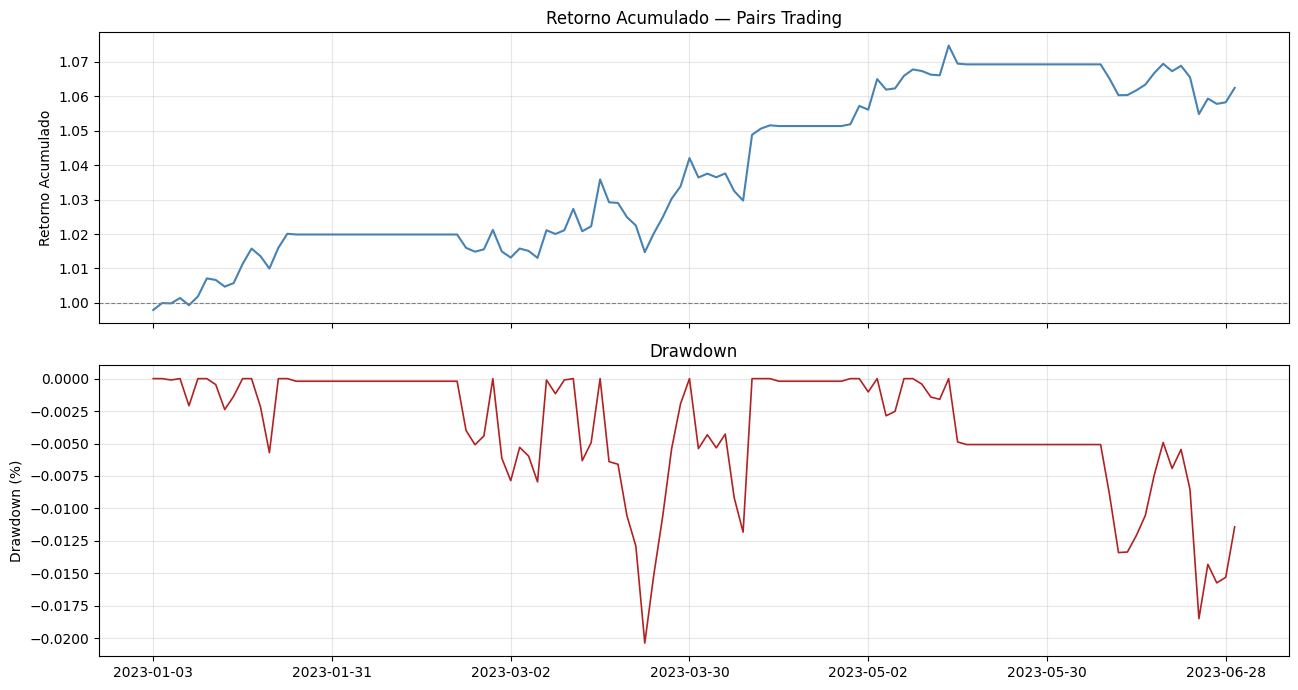

In [17]:
# ── Parâmetros da estratégia ──────────────────────────────────────────────────
ENTRADA   = 2.0
SAIDA     = 0.5
STOP_LOSS = 3.0
CUSTO     = 0.001

# ── Backtest ──────────────────────────────────────────────────────────────────
retornos_diarios = {}

for _, linha in df_pares_validos.iterrows():
    par_nome  = linha['Par']
    at1       = linha['Ativo 1']
    at2       = linha['Ativo 2']
    meia_vida = int(np.ceil(linha['Meia-Vida (Dias Úteis)']))

    col_z    = f"{par_nome}_Z-Score"
    col_beta = f"{par_nome}_Beta_Kalman"

    z    = df_historico_trading[col_z]
    beta = df_historico_trading[col_beta]
    p1   = df_trad[at1]
    p2   = df_trad[at2]

    posicao         = 0
    dias_em_posicao = 0
    retornos_par    = []
    datas           = []

    for i in range(1, len(z)):
        data      = z.index[i]
        z_hoje    = z.iloc[i]
        beta_hoje = beta.iloc[i]

        ret1 = p1.iloc[i] - p1.iloc[i - 1]
        ret2 = p2.iloc[i] - p2.iloc[i - 1]

        # ── Atualiza posição PRIMEIRO ─────────────────────────────────────────
        nova_posicao = posicao

        if posicao == 0:
            if z_hoje >= ENTRADA:
                nova_posicao    = -1
                dias_em_posicao = 0
            elif z_hoje <= -ENTRADA:
                nova_posicao    = +1
                dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje <= -STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo
            elif posicao == -1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje >= STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo

        if nova_posicao != posicao:
            dias_em_posicao = 0

        custo_dia = CUSTO if nova_posicao != posicao else 0.0
        posicao   = nova_posicao

        # ── Calcula retorno DEPOIS de atualizar posição ───────────────────────
        retorno_bruto   = posicao * (ret1 - beta_hoje * ret2)
        retorno_liquido = retorno_bruto - custo_dia

        retornos_par.append(retorno_liquido)
        datas.append(data)

    retornos_diarios[par_nome] = pd.Series(retornos_par, index=datas)

df_retornos = pd.DataFrame(retornos_diarios).fillna(0)

# ── Retorno da carteira com pesos iguais ──────────────────────────────────────
retorno_carteira  = df_retornos.mean(axis=1)
retorno_acumulado = (1 + retorno_carteira).cumprod()
pico              = retorno_acumulado.cummax()
drawdown          = (retorno_acumulado - pico) / pico
mdd               = drawdown.min()
sharpe            = (retorno_carteira.mean() / retorno_carteira.std()) * np.sqrt(252)

# ── Estatísticas ──────────────────────────────────────────────────────────────
print(f"═══ Estatísticas da Estratégia ══════════════════════════════════")
print(f"Pares operados            : {len(df_pares_validos)}")
print(f"Retorno acumulado líquido : {(retorno_acumulado.iloc[-1] - 1) * 100:.2f}%")
print(f"Retorno médio anualizado  : {retorno_carteira.mean() * 252 * 100:.2f}%")
print(f"Volatilidade anualizada   : {retorno_carteira.std() * np.sqrt(252) * 100:.2f}%")
print(f"Sharpe anualizado         : {sharpe:.4f}")
print(f"Maximum Drawdown          : {mdd * 100:.2f}%")

# ── Retorno por par ───────────────────────────────────────────────────────────
retorno_por_par = (1 + df_retornos).prod() - 1
retorno_por_par = retorno_por_par.sort_values()
print(f"\nRetorno acumulado por par:")
print((retorno_por_par * 100).round(2).to_string())
print(f"\nPares lucrativos: {(retorno_por_par > 0).sum()}")
print(f"Pares com perda : {(retorno_por_par < 0).sum()}")

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

retorno_acumulado.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Retorno Acumulado — Pairs Trading')
axes[0].set_ylabel('Retorno Acumulado')
axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

drawdown.plot(ax=axes[1], color='firebrick', linewidth=1.2)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# ── Exportação dos resultados do Período para Excel ───────────────────────────
ARQUIVO = "periodo_2_jan2022_jun2023.xlsx"

# ── Número total de trades ────────────────────────────────────────────────────
total_trades = 0
for par in df_pares_validos['Par']:
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z = df_historico_trading[col_z]
    posicao = 0
    dias_em_posicao = 0
    meia_vida_par = int(np.ceil(
        df_pares_validos.loc[df_pares_validos['Par'] == par, 'Meia-Vida (Dias Úteis)'].values[0]
    ))
    for z_atual in z:
        nova_posicao = posicao
        if posicao == 0:
            if z_atual >= ENTRADA:
                nova_posicao = -1; dias_em_posicao = 0
            elif z_atual <= -ENTRADA:
                nova_posicao = +1; dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_atual <= SAIDA or z_atual <= -STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
            elif posicao == -1:
                if -SAIDA <= z_atual <= SAIDA or z_atual >= STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
        if nova_posicao == 0 and posicao != 0:
            total_trades += 1
            dias_em_posicao = 0
        posicao = nova_posicao

# ── Aba 5: Estatísticas resumidas ─────────────────────────────────────────────
df_estatisticas = pd.DataFrame([{
    'Período de Estimação'       : 'Jul/2021 – Jun/2022',
    'Período de Trading'         : 'Jul/2022 – Dez/2022',
    'Pares Operados'             : len(df_pares_validos),
    'Total de Trades'            : total_trades,
    'Retorno Acumulado (%)'      : round((retorno_acumulado.iloc[-1] - 1) * 100, 2),
    'Retorno Anualizado (%)'     : round(retorno_carteira.mean() * 252 * 100, 2),
    'Volatilidade Anualizada (%)': round(retorno_carteira.std() * np.sqrt(252) * 100, 2),
    'Sharpe Anualizado'          : round(sharpe, 4),
    'Maximum Drawdown (%)'       : round(mdd * 100, 2),
}])

# ── Aba 4: Retorno diário da carteira + acumulado ─────────────────────────────
df_retorno_carteira = pd.DataFrame({
    'Retorno Diário'    : retorno_carteira,
    'Retorno Acumulado' : retorno_acumulado,
    'Drawdown'          : drawdown,
})

# ── Corrige zeros negativos nos retornos por par ──────────────────────────────
df_retornos_limpo = df_retornos.round(8)

# ── Exporta para Excel com múltiplas abas ─────────────────────────────────────
with pd.ExcelWriter(ARQUIVO, engine='openpyxl') as writer:

    # Aba 1 — Pares selecionados
    df_pares_validos.to_excel(
        writer, sheet_name='1_Pares_Selecionados', index=False)

    # Aba 2 — Z-scores do período de trading
    df_historico_trading[
        [c for c in df_historico_trading.columns if '_Z-Score' in c]
    ].to_excel(writer, sheet_name='2_ZScores_Trading')

    # Aba 3 — Retornos diários por par (sem zeros negativos)
    df_retornos_limpo.to_excel(writer, sheet_name='3_Retornos_Por_Par')

    # Aba 4 — Retorno da carteira
    df_retorno_carteira.to_excel(writer, sheet_name='4_Retorno_Carteira')

    # Aba 5 — Estatísticas resumidas
    df_estatisticas.to_excel(
        writer, sheet_name='5_Estatisticas', index=False)

print(f"Arquivo '{ARQUIVO}' salvo com sucesso!")
print(f"\nAbas geradas:")
print(f"  1_Pares_Selecionados : {len(df_pares_validos)} pares")
print(f"  2_ZScores_Trading    : {len([c for c in df_historico_trading.columns if '_Z-Score' in c])} séries")
print(f"  3_Retornos_Por_Par   : {df_retornos_limpo.shape[1]} pares × {df_retornos_limpo.shape[0]} dias")
print(f"  4_Retorno_Carteira   : {len(df_retorno_carteira)} dias")
print(f"  5_Estatisticas       : {total_trades} trades no período")

Arquivo 'periodo_2_jan2022_jun2023.xlsx' salvo com sucesso!

Abas geradas:
  1_Pares_Selecionados : 5 pares
  2_ZScores_Trading    : 11 séries
  3_Retornos_Por_Par   : 5 pares × 122 dias
  4_Retorno_Carteira   : 122 dias
  5_Estatisticas       : 4 trades no período
